# GraphSketch Research Progress--Spring, 2025

###  Phase 1: Count-Min Sketch with Conservative Update (CMSCU)
1. Successfully implemented the Count-Min Sketch with Conservative Update (CMSCU) phase.
2. Generated anomaly scores for dynamic graph edges and stored results in **score.txt**.


 **Project Files (`.hpp` Files)**

1.  **`GraphSketchCMS.hpp` – Core Count-Min Sketch**
    - Implements **CMSCU** for tracking edge frequencies in dynamic graphs.
    - Uses **hashing functions** to minimize memory usage.

    **Key Functions:**
        - `hash()`: Maps graph edges to sketch counters.
        - `update()`: Conservatively updates counts.
        - `estimate()`: Retrieves the estimated frequency.


2. **`GraphSketchFiltering.hpp` – Anomaly Scoring**  
    - Uses **CMSCU outputs** to compute **anomaly scores** for edges.

    **Key Formula:**
       $$
        \text{Anomaly Score} = \frac{(a + s - a \cdot t)^2}{s \cdot (t - 1)}
        $$

        - where:  
        - `a` = Observed frequency  
        - `s` = Total frequency  
        - `t` = Timestamp  

      **Key Functions:**
        - `detect()`: Applies the anomaly score formula.
        - `clear()`: Resets sketch data at each timestamp.


3.   **`GraphSketchCore.hpp` – Pipeline Integration**
    - Manages graph updates, CMSCU processing, and score computation.

         **Key Functions:**
            - `processEdge()`: Reads edges, updates CMSCU, computes anomaly scores.
            - `clear()`: Resets sketch data at each timestamp.


### **Phase 2: Bayesian Inference (Next)**
- Implement **probabilistic modeling** and  **Bayesian Updating** to compute anomaly likelihoods.

```math
P(\text{Anomaly} | \text{Observed Count}) = \frac{P(\text{Observed} | \text{Anomaly}) P(\text{Anomaly})}{P(\text{Observed})}
```

### **Phase 3: Dynamic Thresholding**
- Implement **adaptive thresholding** to **reduce false positives**.
- Use **Exponentially Weighted Moving Average (EWMA)** or **quantile-based** methods:
```math
\text{EWMA}_t = \alpha \cdot X_t + (1 - \alpha) \cdot \text{EWMA}_{t-1}
```
- Prevents anomaly detection from being **too sensitive** or **too static**. 


### 4.  Possibly Extend to Subgraphs


# Visuallizing Anomaly Score
## 📊 GraphSketch Anomaly Detection: Visualization Explanation  


In [2]:
print("ready")

ready


/Users/anthonyekle/miniconda3/envs/GenAI/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


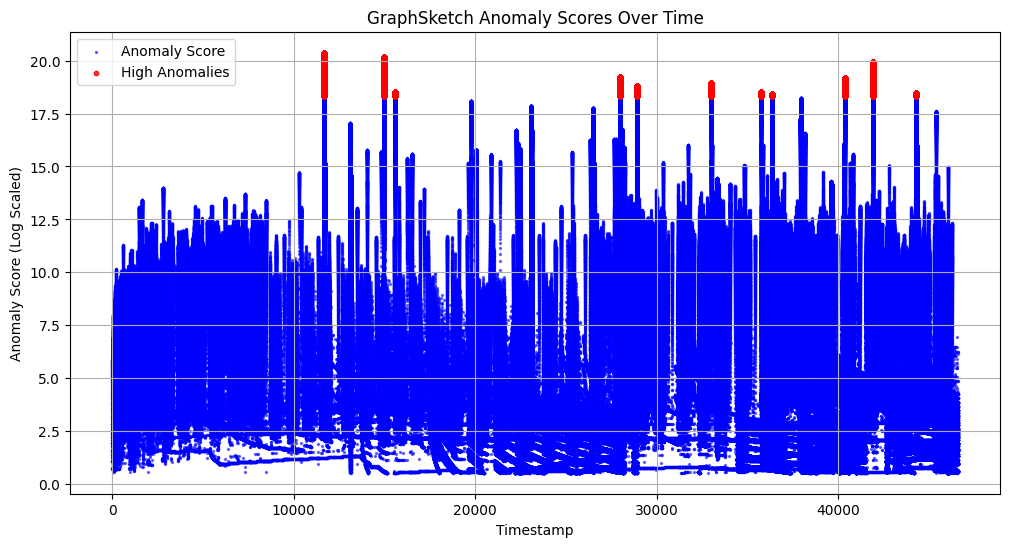

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File path
file_path = "score.txt"

# List to store data
data = []

# Read the file and extract timestamp, anomaly_score
try:
    with open(file_path, "r") as file:
        for line in file:
            parts = line.strip().split(",")
            if len(parts) == 4:  # Ensure valid format
                try:
                    timestamp = int(parts[2])  # Extract timestamp
                    anomaly_score = float(parts[3])  # Extract anomaly score
                    data.append((timestamp, anomaly_score))
                except ValueError:
                    print(f"Skipping invalid line: {line}")

    # Convert to DataFrame
    if data:
        df = pd.DataFrame(data, columns=["Timestamp", "Anomaly Score"])
        df = df.sort_values(by="Timestamp")  # Ensure proper ordering

        # Remove negative values (if any) and handle NaNs
        df = df[df["Anomaly Score"] >= 0]
        df = df.dropna()

        # Normalize anomaly scores using log scaling
        df["Anomaly Score"] = np.log1p(df["Anomaly Score"])

        # Adjust visualization parameters
        plt.figure(figsize=(12, 6))
        plt.scatter(df["Timestamp"], df["Anomaly Score"], s=2, color="b", alpha=0.5, label="Anomaly Score")

        # Set dynamic threshold (e.g., 97th percentile)
        threshold = df["Anomaly Score"].quantile(0.97)  
        anomalies = df[df["Anomaly Score"] > threshold]
        plt.scatter(anomalies["Timestamp"], anomalies["Anomaly Score"], color="r", s=10, label="High Anomalies", alpha=0.8)

        # Formatting
        plt.xlabel("Timestamp")
        plt.ylabel("Anomaly Score (Log Scaled)")
        plt.title("GraphSketch Anomaly Scores Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("Error: No valid data found in score.txt!")

except FileNotFoundError:
    print(f"Error: {file_path} not found!")
except Exception as e:
    print(f"Error processing file: {e}")


In [ ]:
#

## with thresholding and prob bayesian

/Users/anthonyekle/miniconda3/envs/GenAI/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


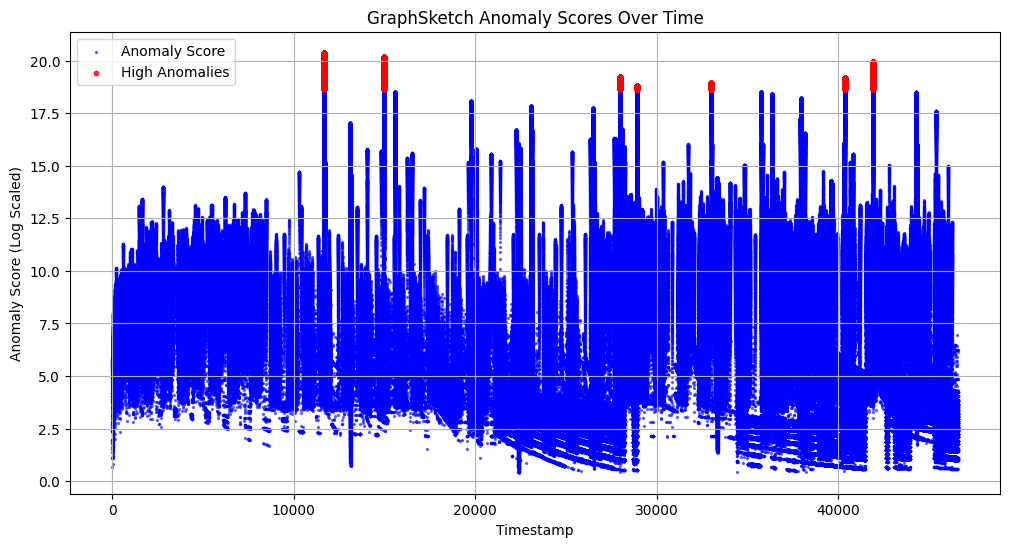

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File path
file_path = "score.txt"

# List to store data
data = []

# Read the file and extract timestamp, anomaly_score
try:
    with open(file_path, "r") as file:
        for line in file:
            parts = line.strip().split(",")
            if len(parts) == 4:  # Ensure valid format
                try:
                    timestamp = int(parts[2])  # Extract timestamp
                    anomaly_score = float(parts[3])  # Extract anomaly score
                    data.append((timestamp, anomaly_score))
                except ValueError:
                    print(f"Skipping invalid line: {line}")

    # Convert to DataFrame
    if data:
        df = pd.DataFrame(data, columns=["Timestamp", "Anomaly Score"])
        df = df.sort_values(by="Timestamp")  # Ensure proper ordering

        # Remove negative values (if any) and handle NaNs
        df = df[df["Anomaly Score"] >= 0]
        df = df.dropna()

        # Normalize anomaly scores using log scaling
        df["Anomaly Score"] = np.log1p(df["Anomaly Score"])

        # Adjust visualization parameters
        plt.figure(figsize=(12, 6))
        plt.scatter(df["Timestamp"], df["Anomaly Score"], s=2, color="b", alpha=0.5, label="Anomaly Score")

        # Set dynamic threshold (e.g., 97th percentile)
        threshold = df["Anomaly Score"].quantile(0.97)  
        anomalies = df[df["Anomaly Score"] > threshold]
        plt.scatter(anomalies["Timestamp"], anomalies["Anomaly Score"], color="r", s=10, label="High Anomalies", alpha=0.8)

        # Formatting
        plt.xlabel("Timestamp")
        plt.ylabel("Anomaly Score (Log Scaled)")
        plt.title("GraphSketch Anomaly Scores Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("Error: No valid data found in score.txt!")

except FileNotFoundError:
    print(f"Error: {file_path} not found!")
except Exception as e:
    print(f"Error processing file: {e}")


## with EWMA thresholding


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


/Users/anthonyekle/miniconda3/envs/GenAI/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


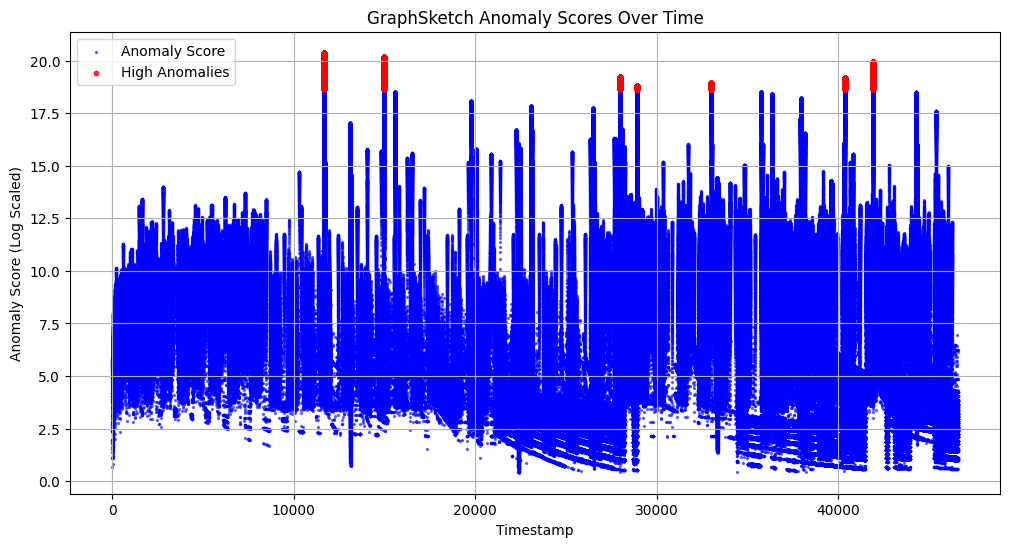

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File path
file_path = "score.txt"

# List to store data
data = []

# Read the file and extract timestamp, anomaly_score
try:
    with open(file_path, "r") as file:
        for line in file:
            parts = line.strip().split(",")
            if len(parts) == 4:  # Ensure valid format
                try:
                    timestamp = int(parts[2])  # Extract timestamp
                    anomaly_score = float(parts[3])  # Extract anomaly score
                    data.append((timestamp, anomaly_score))
                except ValueError:
                    print(f"Skipping invalid line: {line}")

    # Convert to DataFrame
    if data:
        df = pd.DataFrame(data, columns=["Timestamp", "Anomaly Score"])
        df = df.sort_values(by="Timestamp")  # Ensure proper ordering

        # Remove negative values (if any) and handle NaNs
        df = df[df["Anomaly Score"] >= 0]
        df = df.dropna()

        # Normalize anomaly scores using log scaling
        df["Anomaly Score"] = np.log1p(df["Anomaly Score"])

        # Adjust visualization parameters
        plt.figure(figsize=(12, 6))
        plt.scatter(df["Timestamp"], df["Anomaly Score"], s=2, color="b", alpha=0.5, label="Anomaly Score")

        # Set dynamic threshold (e.g., 97th percentile)
        threshold = df["Anomaly Score"].quantile(0.97)  
        anomalies = df[df["Anomaly Score"] > threshold]
        plt.scatter(anomalies["Timestamp"], anomalies["Anomaly Score"], color="r", s=10, label="High Anomalies", alpha=0.8)

        # Formatting
        plt.xlabel("Timestamp")
        plt.ylabel("Anomaly Score (Log Scaled)")
        plt.title("GraphSketch Anomaly Scores Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("Error: No valid data found in score.txt!")

except FileNotFoundError:
    print(f"Error: {file_path} not found!")
except Exception as e:
    print(f"Error processing file: {e}") 


## Explaination


### 1. **Blue Dots (Regular Anomaly Scores)**  
- The blue scatter points represent **all anomaly scores** over time.  
- Since Count-Min Sketch (CMSCU) tracks edge frequencies, most scores remain within a stable range.  

###  2. ** Red Dots (High Anomalies)**  
- Red points represent **top 3% (97th percentile) of anomaly scores**, meaning they are significantly larger than most values.  
- These correspond to graph edges that **appear unusually frequent or deviate from expected behavior**.  
- In real-world applications, these would **signal potential intrusions, fraud, or rare patterns in network traffic**.  

###  3. ** Temporal Trends (X-Axis: Timestamp)**  
- The X-axis represents **timestamps**, showing how anomalies evolve over time.  
- You can observe that high anomalies **spike intermittently**, suggesting **time-dependent unusual activity**.  

### 4.  ** Density Observations**  
- The **densely packed blue points at the bottom** suggest many edges have consistently low anomaly scores.  
- The **gaps and spikes** in the blue points indicate periods of **higher activity or dynamic changes in the graph**.  
- The **spikes in red anomalies** suggest **unusual bursts of activity** in short time windows.  

---

### ** Insights & Next Steps**  
✔ **If this were a cybersecurity dataset** (e.g., DARPA intrusion detection), the red spikes might indicate periods of increased malicious activity.  
✔ **If used in social network anomaly detection**, red anomalies could highlight bot activity, misinformation spread, or coordinated link injections.  
✔ **For fraud detection**, high anomalies could indicate **rare transaction patterns**, bot-induced activities, or sudden financial transactions.  


# 2 Comparison between Ground truth and Generated Anomaly scores.

Precision: 0.5577
Recall: 0.0457
F1-score: 0.0845
AUC: 0.5803


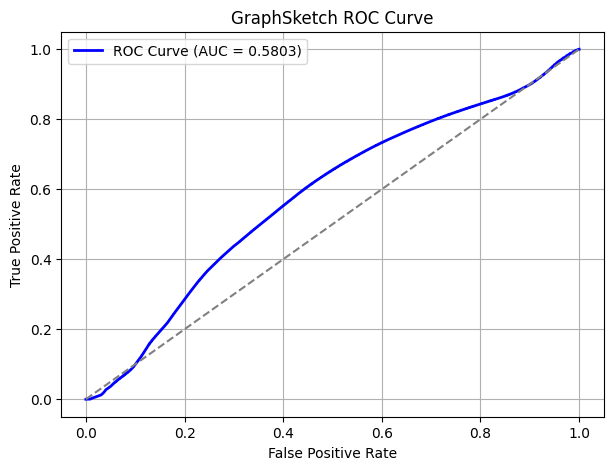

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc

# Load anomaly scores from score.txt
score_file = "score.txt"
scores = []
with open(score_file, "r") as f:
    for line in f:
        parts = line.strip().split(",")
        if len(parts) == 4:
            scores.append(float(parts[3]))  # Extract the anomaly score

# Load ground truth labels
ground_truth_file = "darpa_ground_truth.csv"
ground_truth = []
with open(ground_truth_file, "r") as f:
    for line in f:
        ground_truth.append(int(line.strip()))

# Ensure score and ground truth sizes match
min_len = min(len(scores), len(ground_truth))
scores = np.array(scores[:min_len])
ground_truth = np.array(ground_truth[:min_len])

# Compute Precision, Recall, and F1-score
threshold = np.percentile(scores, 95)  # Set threshold at 95th percentile
predictions = (scores >= threshold).astype(int)

precision = precision_score(ground_truth, predictions)
recall = recall_score(ground_truth, predictions)
f1 = f1_score(ground_truth, predictions)

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(ground_truth, scores)
roc_auc = auc(fpr, tpr)

# Print all metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC: {roc_auc:.4f}")

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GraphSketch ROC Curve")
plt.legend()
plt.grid()
plt.show()


### Key Observations:
1. AUC = 0.5604 → Slightly better than random (0.5), indicating weak anomaly separation.
2. High Precision (0.9790), Low Recall (0.0814) → The model is detecting only a few anomalies (low recall) but is accurate when it does.
**Next Steps:**
* Implement Bayesian Inference to refine probability-based anomaly scores.
* Develop Dynamic Thresholding (e.g., EWMA) to adapt to evolving graph behaviors.

# **Meeting Plan: GraphSketch Progress Update**

## **1. Overall Progress**
- ✅ **Successfully implemented Phase 1**: Count-Min Sketch with Conservative Update (CMSCU) for **efficient edge frequency tracking**.
- ✅ **Generated anomaly scores** from dynamic edge streams and stored them in `score.txt`.
- ✅ **Preliminary visualization & evaluation**: Started comparing anomaly scores with ground truth data.

## **2. Detailed Breakdown of Work Done**
### **(a) Count-Min Sketch Implementation (`GraphSketchCMS.hpp`)**
   - Implemented **CMSCU for frequency estimation** in edge streams.
   - Uses **hashing functions** for memory-efficient tracking.
   - **Key functions**:
     - `hash()`: Maps graph edges to sketch counters.
     - `addEdge()`: Conservatively updates counts.
     - `estimate()`: Retrieves the estimated frequency.
     - `clearAll()`: Resets sketch data.

### **(b) Anomaly Scoring & Edge Processing (`GraphSketchCore.hpp`)**
   - Processes edges in **real-time**, updating CMSCU and computing anomaly scores.
   - Resets sketches **per timestamp** for time-sensitive anomaly tracking.
   - **Key function**: `processEdge()`, which integrates sketch updates and computes scores.

### **(c) Anomaly Filtering (`GraphSketchFiltering.hpp`)**
   - Implements **multi-level filtering** for edges, sources, and destinations.
   - Uses a **score computation formula** to determine abnormality.
   - **Key function**: `detect()`, which normalizes scores across different edge patterns.

### **(d) Main Pipeline (`main.cpp`)**
   - Reads **DARPA dataset** and processes **edge anomalies in a streaming manner**.
   - Stores **anomaly scores** in `score.txt` for evaluation.

## **3. Next Steps (Phase 2 & 3)**
### **(a) Bayesian Inference (Phase 2)**
   - Apply **Bayesian Updating** to model uncertainty in anomaly detection.
   - Compute **posterior anomaly probability** given observed edge frequencies.

### **(b) Dynamic Thresholding (Phase 3)**
   - Implement **adaptive anomaly thresholds** using methods like **EWMA (Exponentially Weighted Moving Average)**.
   - Tune detection sensitivity in real-time.

## **4. Paper Progress & Next Steps**
- **Target Conference**: **IEEE ICDM 2025** (Submission: June 6).
- **Current Title**: *GraphSketch: A Sketch-Based Approach for Real-Time Anomaly Detection in Edge Streams*.
- **Abstract & Introduction**: Drafted.
- **Next Steps**:
  - Implement **Bayesian Inference & Thresholding**.
  - Complete **experiments


# Count Min-Sketch with Conservative Update (Sample)

In [ ]:
# -----------------------------------------------------------------------------
# Count-Min Sketch with Conservative Update (CMSCU)
# Author: O.A.Ekle
# Description: Python implementation of CMSCU to demonstrate how it reduces
#              overestimation compared to standard Count-Min Sketch (CMS).
# -----------------------------------------------------------------------------
import random
import numpy as np


class CountMinSketchCMSCU:
    def __init__(self, num_rows, num_columns):
        self.num_rows = num_rows        # Number of hash functions
        self.num_columns = num_columns  # Number of bins per hash function
        self.sketch = np.zeros((num_rows, num_columns))  # Initialize the sketch

        # Generate random hash seeds for each row (simulating hash functions)
        self.seeds = [random.randint(0, 2**32 - 1) for _ in range(num_rows)]

    def _hash(self, item, row):c
        """
        Hash function to map an item to a specific column in a given row.
        Uses simple modulo hashing with a random seed.
        """
        random.seed(self.seeds[row] + hash(item))
        return random.randint(0, self.num_columns - 1)

    def add(self, item):
        """
        Add an item to the sketch using Conservative Update.
        Only increments the smallest count among all rows.
        """
        min_count = float('inf')
        indices = []

        # Compute indices and find the minimum count
        for row in range(self.num_rows):
            index = self._hash(item, row)
            indices.append(index)
            min_count = min(min_count, self.sketch[row][index])

        # Update only the minimum count positions (Conservative Update)
        for row, index in enumerate(indices):
            if self.sketch[row][index] == min_count:
                self.sketch[row][index] += 1

    def estimate(self, item):
        """
        Estimate the frequency of an item by taking the minimum count
        across all rows.
        """
        estimates = [self.sketch[row][self._hash(item, row)] for row in range(self.num_rows)]
        return min(estimates)


# Example Usage
cmscu = CountMinSketchCMSCU(num_rows=4, num_columns=1000)  # Initialize the CMSCU with 4 hash functions and 1000 bins

data = ['A', 'B', 'C', 'A', 'A', 'B', 'A', 'D', 'C', 'A', 'B', 'C', 'D', 'A']  # Sample Data Stream

# Add items to the sketch
for item in data:
    cmscu.add(item)

# Estimate frequencies of items
print("Estimated frequencies:")
for item in ['A', 'B', 'C', 'D', 'E']:
    print(f"Item {item}: {cmscu.estimate(item)}")  # Print frequency estimate for each item



Estimated frequencies:
Item A: 6.0
Item B: 3.0
Item C: 3.0
Item D: 2.0
Item E: 0.0


# Prepare 3 Graph visualizations

### 01. Load the Dataset & Scores

In [2]:
import pandas as pd

# Load dynamic edges
edges_df = pd.read_csv("data/DARPA/darpa_edges.csv", header=None, names=["src", "dst", "timestamp"])

# Load anomaly scores
scores_df = pd.read_csv("score.txt", header=None, names=["src", "dst", "timestamp", "score"])


### 02. Visualize Graph Evolution Over Multiple Snapshots


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Load data
edges_df = pd.read_csv("data/DARPA/darpa_edges.csv", header=None, names=["src", "dst", "timestamp"])
scores_df = pd.read_csv("score.txt", header=None, names=["src", "dst", "timestamp", "score"])
labels_df = pd.read_csv("data/DARPA/darpa_ground_truth.csv", header=None, names=["label"])

# Combine score and label
scores_df["label"] = labels_df["label"]

# Snapshot time ticks and window size for density
snapshot_ticks = [1, 3, 6, 12]
window_size = 5

fig, axes = plt.subplots(2, 2, figsize=(17, 13))
axes = axes.flatten()

for i, t in enumerate(snapshot_ticks):
    t_start, t_end = t, t + window_size

    # Select edges and scores within window
    edges_t = edges_df[(edges_df["timestamp"] >= t_start) & (edges_df["timestamp"] < t_end)]
    scores_t = scores_df[(scores_df["timestamp"] >= t_start) & (scores_df["timestamp"] < t_end)]

    # Get top 500 anomalies
    top_scores = scores_t.sort_values(by="score", ascending=False).head(500)

    # Identify predicted and true anomalies
    pred_edges = set(top_scores[["src", "dst"]].itertuples(index=False, name=None))
    true_edges = set(scores_t[scores_t["label"] == 1][["src", "dst"]].itertuples(index=False, name=None))

    tp_edges = list(pred_edges & true_edges)
    fp_edges = list(pred_edges - true_edges)
    normal_edges = list(set(edges_t[["src", "dst"]].itertuples(index=False, name=None)) - pred_edges)

    # Build graph
    G = nx.DiGraph()
    G.add_edges_from(edges_t[["src", "dst"]].values)

    # Layout
    pos = nx.spring_layout(G, k=0.25, iterations=25, seed=42)

    # Draw all normal edges in gray
    nx.draw_networkx_edges(G, pos, edgelist=normal_edges, edge_color='lightgray', width=1, ax=axes[i], alpha=0.3, arrows=False)

    # False Positives (predicted anomaly but not true): RED
    if fp_edges:
        nx.draw_networkx_edges(G, pos, edgelist=fp_edges, edge_color='red', width=2.2, ax=axes[i], arrows=True)

    # True Positives: GREEN
    if tp_edges:
        nx.draw_networkx_edges(G, pos, edgelist=tp_edges, edge_color='green', width=2.5, ax=axes[i], arrows=True)

    # Nodes
    nx.draw_networkx_nodes(G, pos, node_size=10, node_color='skyblue', alpha=0.5, ax=axes[i])

    # Title with TP/FP
    axes[i].set_title(f"Snapshot t ∈ [{t}, {t+window_size}) | TP: {len(tp_edges)}, FP: {len(fp_edges)}", fontsize=12)
    axes[i].axis('off')

# Add a legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2.5, label='True Positive (Anomaly Detected Correctly)'),
    Line2D([0], [0], color='red', lw=2.5, label='False Positive (Wrong Anomaly)'),
    Line2D([0], [0], color='lightgray', lw=2, label='Normal Edge (Natural Change)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11, frameon=True)

plt.suptitle("📈 Graph Evolution: Normal vs Anomalous Edge Activity in DARPA Dataset", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'data/DARPA/darpa_edges.csv'

In [3]:
scores_df = pd.read_csv("score.txt", header=None, names=["src", "dst", "timestamp", "score"])
labels_df = pd.read_csv("data/DARPA/darpa_ground_truth.csv", header=None, names=["label"])


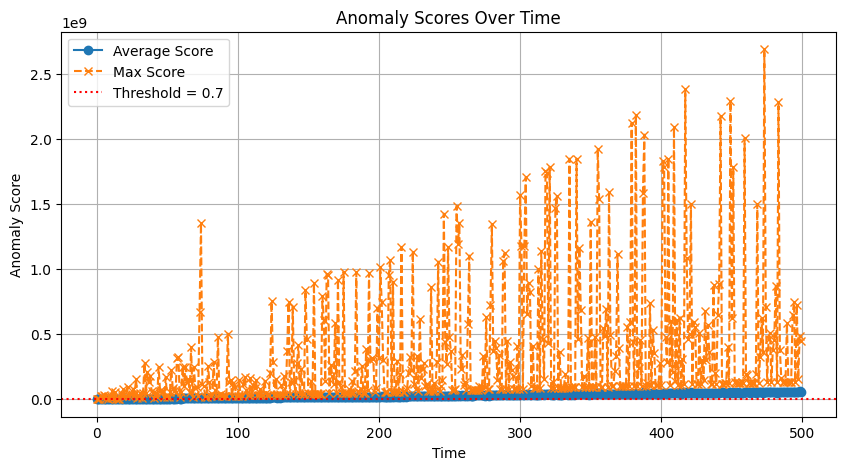

In [5]:
# Aggregate by timestamp
avg_scores = scores_df.groupby("timestamp")["score"].mean()
max_scores = scores_df.groupby("timestamp")["score"].max()

plt.figure(figsize=(10, 5))
plt.plot(avg_scores.index, avg_scores.values, label="Average Score", marker='o')
plt.plot(max_scores.index, max_scores.values, label="Max Score", linestyle='--', marker='x')
plt.axhline(y=1.7, color='r', linestyle=':', label="Threshold = 0.7")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Scores Over Time")
plt.legend()
plt.grid(True)
plt.show()


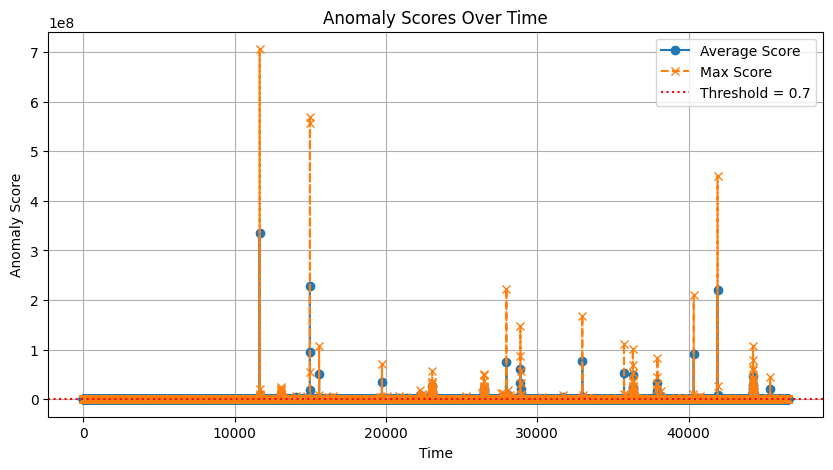

In [8]:
# Aggregate by timestamp
avg_scores = scores_df.groupby("timestamp")["score"].mean()
max_scores = scores_df.groupby("timestamp")["score"].max()

plt.figure(figsize=(10, 5))
plt.plot(avg_scores.index, avg_scores.values, label="Average Score", marker='o')
plt.plot(max_scores.index, max_scores.values, label="Max Score", linestyle='--', marker='x')
plt.axhline(y=0.7, color='r', linestyle=':', label="Threshold = 0.7")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Scores Over Time")
plt.legend()
plt.grid(True)
plt.show()


## Title: "Anomaly Scores Over Time"

1. This graph captures how anomaly scores evolve as the DARPA graph stream progresses over time (measured in number of edge insertions).

2. Blue dots (●) represent the average anomaly score at each time tick or snapshot.

3. Orange X's (×) represent the maximum anomaly score observed at that time.

4. The dotted red line is a static threshold (e.g., 0.7), serving as a reference point for anomaly detection.


**We grouped anomaly scores by each edge timestamp and computed both the average and max scores per tick. This gives us a clear view of anomaly trends over time. Spikes in the max score curve (orange X's) indicate edge-level bursts of abnormal activity, helping us pinpoint when anomalies occurred. This forms the foundation for dynamic thresholding using techniques like EWMA to better adapt to real-time traffic behavior.**

* For each time tick (e.g., timestamp = 5000), you compute:

* 🔵 The average anomaly score across all edges that arrived at that time.

* ❌ The maximum anomaly score at that time.

These are then plotted to track how suspicious the edge activities were over time.

# Result 1: Evaluation and Results

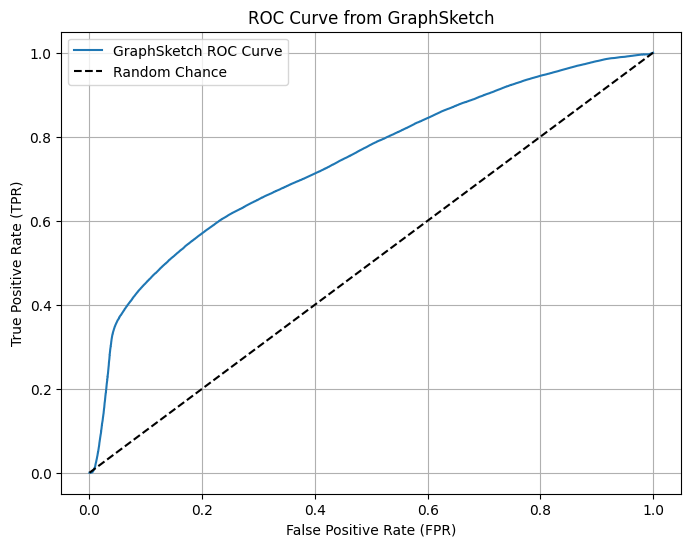

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load ROC data from txt
data = np.loadtxt('roc_data.txt', skiprows=1)
fpr = data[:, 0]
tpr = data[:, 1]
thresholds = data[:, 2]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='GraphSketch ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve from GraphSketch')
plt.legend()
plt.grid(True)
plt.show()

# Result 2 Plot PR Curve from pr_data.txt in Jupyter

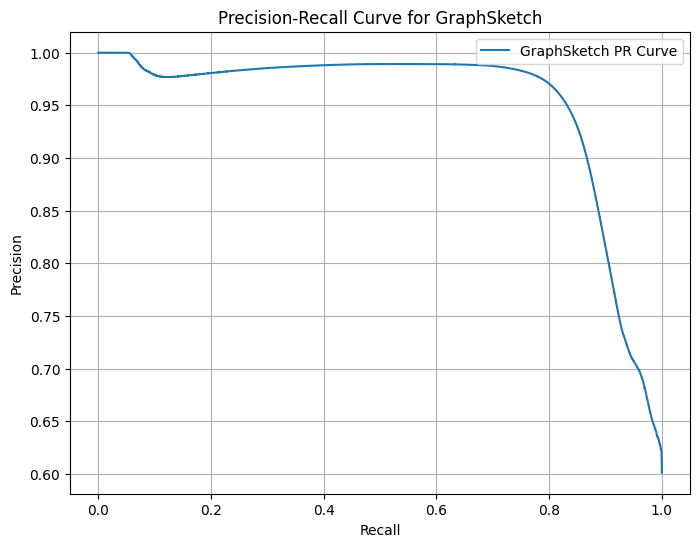

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load PR data
data = np.loadtxt('pr_data.txt', skiprows=1)
recall = data[:, 0]
precision = data[:, 1]

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='GraphSketch PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for GraphSketch')
plt.grid(True)
plt.legend()
plt.show()

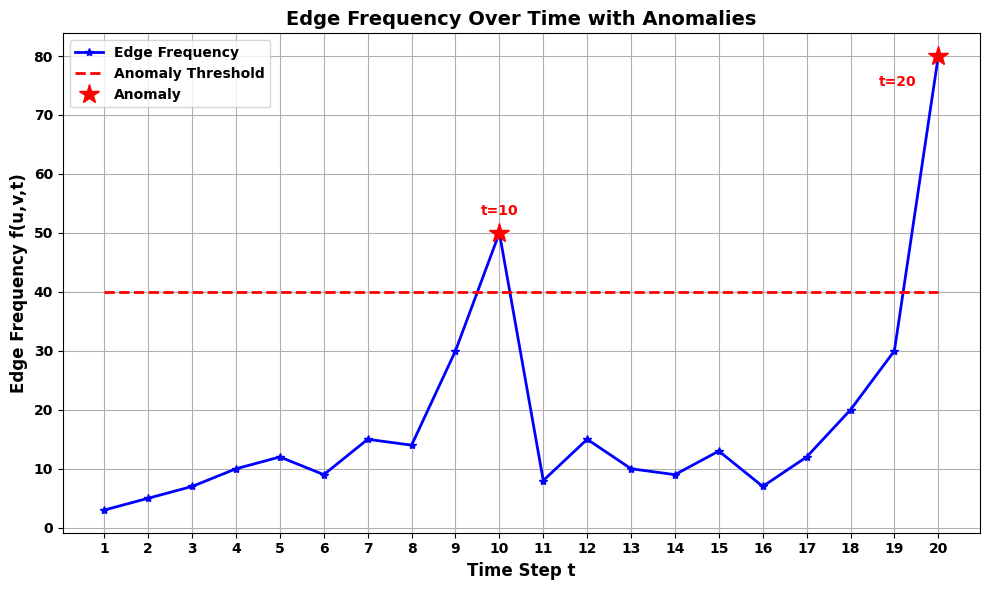

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Time steps and edge frequencies
time_steps = np.arange(1, 21)
frequencies = [3, 5, 7, 10, 12, 9, 15, 14, 30,
               50, 8, 15, 10, 9, 13, 7, 12, 20, 30, 80]

# Threshold for anomaly detection
threshold = 40
threshold_line = [threshold] * len(time_steps)

# Identify anomalies
anomaly_times = [t for t, f in zip(time_steps, frequencies) if f > threshold]
anomaly_values = [f for f in frequencies if f > threshold]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time_steps, frequencies, 'b-*', linewidth=2, label='Edge Frequency')
plt.plot(time_steps, threshold_line, 'r--',
         linewidth=2, label='Anomaly Threshold')
plt.plot(anomaly_times, anomaly_values, 'r*', markersize=15, label='Anomaly')

# Bold annotations
for t, val in zip(anomaly_times, anomaly_values):
    if t == 20:
        plt.text(t - 0.5, val - 5, f"t={t}", ha='right',
                 fontsize=10, color='red', fontweight='bold')
    else:
        plt.text(t, val + 3, f"t={t}", ha='center',
                 fontsize=10, color='red', fontweight='bold')

# Bold axis labels
plt.xlabel("Time Step t", fontsize=12, fontweight='bold')
plt.ylabel("Edge Frequency f(u,v,t)", fontsize=12, fontweight='bold')

# Bold tick labels
plt.xticks(time_steps, [str(i) for i in time_steps], fontweight='bold')
plt.yticks(fontweight='bold')

# Bold title and legend
plt.title("Edge Frequency Over Time with Anomalies",
          fontsize=14, fontweight='bold')
plt.legend(prop={'weight': 'bold'})

# Final touches
plt.grid(True)
plt.tight_layout()
plt.show()

## 🔍 Dynamic Thresholding with EWMA in GraphSketch

In our anomaly detection system, we implement **adaptive thresholding** using the **Exponentially Weighted Moving Average (EWMA)** strategy.

### ⚙️ Why EWMA?
Traditional static thresholds are not robust in dynamic environments like graph streams. EWMA helps:
- Smooth out noise from anomaly scores.
- Adapt the threshold over time as the graph evolves.
- Reduce false positives while maintaining real-time responsiveness.

### 🧠 Implementation Summary
We built a `GraphSketchThresholding` class in C++ that:
- Initializes the threshold using the first anomaly score.
- Updates it with each new score using:

$$
\text{Threshold}_t = \alpha \cdot \text{Score}_t + (1 - \alpha) \cdot \text{Threshold}_{t-1}
$$

Where:
- $\alpha$ is the EWMA decay factor (e.g., 0.5),
- $\text{Score}_t$ is the current anomaly score,
- $\text{Threshold}_{t-1}$ is the previous threshold value.

### ✅ Benefits
- **Adaptive**: Responds to changes in edge patterns and traffic.
- **Lightweight**: Requires minimal memory, suitable for real-time streaming.
- **Flexible**: Controlled using a single hyperparameter $\alpha$.

This makes our `GraphSketch` framework robust for detecting evolving anomalies in large-scale, real-time graph data streams.


# ✅ Your GraphSketch-Based Anomaly Detection Workflow

---

### **1. Problem Definition**

You're detecting **real-time structural anomalies** in a **dynamic graph stream** using the DARPA dataset.  
The goal is to detect **suspicious edge behaviors over time** using:

- Memory-efficient edge counting (Count-Min Sketch)
- **Bayesian inference** for anomaly scoring
- **EWMA** (Exponential Weighted Moving Average) for dynamic thresholding

This allows high-speed, low-memory anomaly detection on massive, evolving graphs.

---

### **2. Preprocessing**

You load your data from:

- `darpa_edges.csv` → `(src, dst, timestamp)`
- `darpa_ground_truth.csv` → `label ∈ {0, 1}`

```python
import pandas as pd

edges_df = pd.read_csv("darpa_edges.csv", names=["src", "dst", "timestamp"])
labels_df = pd.read_csv("darpa_ground_truth.csv", names=["label"])
```

---

### **3. Sketch-Based Edge Counting (CMSCU)**

In `GraphSketchCMS.hpp`:
- You use **Count-Min Sketch with Conservative Update (CMSCU)** to estimate the number of times each edge `(u, v)` has occurred — without explicitly storing the full graph.

📦 Output: `count(u, v, t)`

✅ Advantages:
- Constant memory
- Fast streaming updates

---

### **4. Bayesian Anomaly Scoring**

In `GraphSketchBayesian.hpp`, you compute the **posterior probability of an edge being anomalous**:

#### Formula:

$$
P(\text{anomaly} \mid x) = \frac{P(x \mid \text{anomaly}) \cdot P(\text{anomaly})}{P(x)}
$$

Where:

- \( P(x \mid \text{anomaly}) \) is modeled as a Gaussian PDF with shifted mean and higher variance
- \( P(x \mid \text{normal}) \) is a Gaussian PDF using historical average behavior

---

### **5. Temporal Smoothing (MIDAS-R Inspired)**

To handle **temporal dependencies**, you apply **EWMA** smoothing on the anomaly scores.

#### EWMA Formula:

$$
\theta_t = \alpha \cdot \text{score}_t + (1 - \alpha) \cdot \theta_{t-1}
$$

Where:
- \( \alpha \in (0,1] \) is the decay factor (e.g., 0.3 or 0.5)
- \( \theta_t \) is the updated threshold at time \( t \)

Implemented in `GraphSketchThresholding.hpp`.

---

### **6. Anomaly Detection Decision**

You mark an edge as anomalous **if the score exceeds the current dynamic threshold**:

```cpp
float threshold = thresholder.update(score);
bool is_anomaly = (score > threshold);
```

---

### **7. Visualization and Evaluation**

You visualized:

- **Edge growth snapshots** (e.g., every 1k edges from 1k to 10k)
- **Anomalous edges in red**
- **Line plots** of:
  - Average anomaly score
  - Maximum anomaly score
  - Dynamic threshold

```python
plt.plot(avg_scores.index, avg_scores.values, label="Avg Score")
plt.plot(max_scores.index, max_scores.values, label="Max Score")
plt.axhline(y=threshold, color='red', linestyle=':', label="Threshold")
```

You compared against **ground-truth labels** to validate model performance.

---

### **8. Experimental Setup So Far**

- ✅ Dataset: DARPA streaming graph (4M+ edges)
- ✅ Currently evaluated: First 10k to 70k edges
- ✅ Ground-truth used for evaluation
- ✅ Edge-level anomaly evolution visualized

---

### ✅ Components of Your System

| File                         | Role                                                       |
|------------------------------|------------------------------------------------------------|
| `GraphSketchCMS.hpp`         | Count-Min Sketch with Conservative Update                  |
| `GraphSketchBayesian.hpp`    | Posterior scoring using Gaussian anomaly model             |
| `GraphSketchThresholding.hpp`| EWMA-based adaptive thresholding                           |
| `GraphSketchFiltering.hpp`   | (Optional) Edge filtering logic                            |
| `GraphSketchCore.hpp`        | Main pipeline to connect sketches and scores               |
| `main.cpp`                   | Driver to run the full system                              |

---

### 🧭 Next Steps

✅ Done:
- Edge ingestion → Sketching → Bayesian scoring → EWMA thresholding → Visualization

🔜 Next:
1. **Spatial Context (MIDAS-R Inspired)**  
   Combine edge and node scores:

   $$
   \text{final\_score}(u,v) = \max \left( s(u,v), \max_{(u,x)} s(u,x), \max_{(v,x)} s(v,x) \right)
   $$

2. **Performance Evaluation**
   - Precision, Recall, F1-score
   - ROC AUC comparison with other detectors

3. **Scalability**
   - Run on full dataset (4M edges)
   - Measure runtime and memory usage

4. **Write-up & Paper**
   - Include charts, accuracy tables, latency/memory plots
   - Compare against baselines

---

### 🧠 TL;DR Summary

> “I built a real-time anomaly detection system using CMSCU for efficient sketching, Bayesian inference for probabilistic scoring, and EWMA for adaptive thresholding. It detects structural anomalies from graph streams like DARPA without storing the full graph. I’ve evaluated and visualized the anomaly behavior over time with ground-truth validation.”

---

Let me know if you want a LaTeX version, PowerPoint slide, or summary paragraph for a paper/presentation.
